# Exploration of influence of cycling on ASHP performance
This builds some simple decision trees to see whether the cycling features can help diagnose causes for under performance. The models built here are not intended for actual deployment, but to aid understanding of performance in the EoH trial.

The core finding is that a simple method of detecting cycles does a reasonable job of helping group heat pumps into intuitive categories (e.g. long cycles, low flow temperatures) that go some way to separating out causes of poor performance. Unsurprisingly, the best performing heat pumps have long cycles at low flow temperatures with only short gaps between them.

I think a good next step would be to explicitly build (probably rule-based) features designed to detect:
- low flow temperatures but cycles are shortened because the heat pump can't operate at low enough power (oversized heat pump or min flow temperature needs raising)
- seperating out "high constant flow temp" from "ramping up flow temp" and using those to recommend an action when cycles are short and gaps are long (though do they have the same action - adjust weather compensation curve?)
- identifying high flow temp, long-ish cycle, short gap heat pumps, as these probably can't just tweak the flow temp

In [530]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
import plotly.express as px
import graphviz

# Input data is all ASHPs that were included in the original EoH analysis, with cycling features calculated
homes_with_features = pd.read_csv("homes_with_features.csv")

# There are a few null values in the installation data - fill these with 0s
homes_with_features.fillna(0, inplace=True)

homes_with_features.columns

Index(['Property_ID', 'HP_Installed', 'HP_Brand', 'HP_Model', 'HP_Size_kW',
       'HP_Refrigerant', 'SPFH4_selected_window',
       'HP_Energy_Output_selected_window',
       'Mean_annual_SH_flow_temp_selected_window',
       'Mean_annual_HW_flow_temp_selected_window', 'Selected_window_start',
       'Selected_window_end', 'Delivery_Contractor', 'Name_Survey',
       'Name_Install', 'MCS_Flow_Temp', 'MCS_SCOP', 'MCS_SHLoad', 'MCS_Hloss',
       'MCS_SHAnnual', 'MCS_DHWAnnual', 'median_on_duration',
       'median_off_duration', 'median_hw_duration', 'median_flow_temp',
       'median_temp_change', 'mean_power', 'mean_modulation_pct',
       'median_cycles_per_day', 'median_internal_temp_winter',
       'tenth_pct_internal_temp_winter', 'percentage_time_on',
       'annual_hot_water_demand', 'annual_heating_demand',
       'power_weighted_flow_temperature'],
      dtype='object')

In [531]:
# Create general features
homes_with_features["actual_DHW_vs_design_DHW"] = homes_with_features['annual_hot_water_demand'] / homes_with_features['MCS_DHWAnnual']
homes_with_features["actual_annual_SH_vs_design_SH"] = homes_with_features['annual_heating_demand'] / homes_with_features['MCS_SHAnnual']
homes_with_features["HP_Size_vs_SHLoad"] = homes_with_features['HP_Size_kW'] / homes_with_features['MCS_SHLoad']
homes_with_features["HP_Size-SHLoad"] = homes_with_features['HP_Size_kW'] - homes_with_features['MCS_SHLoad']
homes_with_features["DHW%"] = homes_with_features['annual_hot_water_demand'] / (homes_with_features['annual_hot_water_demand'] + homes_with_features['annual_heating_demand'])
homes_with_features["on_to_off_duration_ratio"] = homes_with_features['median_on_duration'] / homes_with_features['median_off_duration']
homes_with_features["internal_temp_range"] = homes_with_features["median_internal_temp_winter"] - homes_with_features["tenth_pct_internal_temp_winter"]


In [532]:
# Flag specific groups
homes_with_features["Daikin_control_issue"] = (homes_with_features["HP_Brand"] == "Daikin") & (homes_with_features["median_off_duration"] <= 6)
homes_with_features["high_flow_temp"] = (homes_with_features["median_flow_temp"] >= 40)
homes_with_features["low_modulation"] = (homes_with_features["mean_modulation_pct"] < 30)
homes_with_features["high_modulation"] = (homes_with_features["mean_modulation_pct"] >= 50)
homes_with_features["lower_than_expected_SH"] = (homes_with_features["actual_annual_SH_vs_design_SH"] < 0.33)
homes_with_features["high_dhw_usage"] = (homes_with_features["DHW%"] > 0.3)
homes_with_features["high_internal_temp_range"] = (homes_with_features["internal_temp_range"] > 2)
homes_with_features["install kW lt design kW"] = (homes_with_features["HP_Size-SHLoad"] < -1)
homes_with_features["install kW gt design kW"] = (homes_with_features["HP_Size-SHLoad"] > 1)
homes_with_features["short on, short off"] = (homes_with_features["median_on_duration"] <= 30) & (homes_with_features["median_on_duration"] <= 20)
homes_with_features["high flow temp slope"] = (homes_with_features["median_temp_change"] < 10)
homes_with_features["on <30%"] = (homes_with_features["percentage_time_on"] < 30)


#homes_with_features = homes_with_features[~homes_with_features["Daikin_control_issue"]]

# Low flow temperature but shorter cycles because heat pump can't operate at low enough power (oversized heat pum or min flow temp needs raising)
# High flow temp, long cycle, short gap heat pumps = undersized?

In [533]:
# Oversizing indicators
homes_with_features["Oversized: low flow temp but short cycles"] = (homes_with_features["median_flow_temp"] < 40) & (homes_with_features["median_on_duration"] <= 20)
homes_with_features["Oversized: low modulation %"] = (homes_with_features["mean_modulation_pct"] < 30)
homes_with_features["Oversized: install kW > design + 1"] = (homes_with_features["HP_Size-SHLoad"] >= 1)
homes_with_features["Oversized: actual heating demand << design"] = (homes_with_features["actual_annual_SH_vs_design_SH"] <= 0.4)
homes_with_features["# Oversizing Indicators"] = homes_with_features[homes_with_features.columns[homes_with_features.columns.str.contains("Oversized")].to_list()].sum(axis=1)

In [534]:
homes_with_features.groupby("# Oversizing Indicators")["SPFH4_selected_window"].agg(["median", "count"])

,median,count
# Oversizing Indicators,,
0,2.8360,88
1,2.8285,184
2,2.7155,116
3,2.6010,35
4,2.8070,5


In [535]:
# Undersizing indicators
homes_with_features["Undersized: install kW < design"] = (homes_with_features["HP_Size-SHLoad"] < 0)
homes_with_features["Undersized: high modulation %"] = (homes_with_features["mean_modulation_pct"] > 50)
homes_with_features["Undersized: high flow temp with long cycles"] = (homes_with_features["median_flow_temp"] >= 40) & (homes_with_features["median_on_duration"] > 20)
homes_with_features["# Undersizing Indicators"] = homes_with_features[homes_with_features.columns[homes_with_features.columns.str.contains("Undersized")].to_list()].sum(axis=1)

In [536]:
homes_with_features.groupby(['Undersized: high flow temp with long cycles', "Undersized: high modulation %", "Undersized: install kW < design"])["SPFH4_selected_window"].agg(["median", "count"])

median  \
Undersized: high flow temp with long cycles Undersized: high modulation % Undersized: install kW < design           
False                                       False                         False                            2.8470   
                                                                          True                             2.7030   
                                            True                          False                            2.7440   
                                                                          True                             2.6585   
True                                        False                         False                            2.7545   
                                                                          True                             2.7430   
                                            True                          False                            2.6775   
                                                                          True                             2.7210   

                                                                                                           count  
Undersized: high flow temp with long cycles Undersized: high modulation % Undersized: install kW < design         
False                                       False                         False                              248  
                                                                          True                                12  
                                            True                          False                               32  
                                                                          True                                12  
True                                        False                         False                               32  
                                                                          True                                 5  
                                            True                          False                               80  
                                                                          True                                 7

In [537]:
homes_with_features.groupby('# Undersizing Indicators')["SPFH4_selected_window"].agg(["median", "count"])

,median,count
# Undersizing Indicators,,
0,2.8470,248
1,2.7435,76
2,2.6740,97
3,2.7210,7


In [538]:
# Weather compensation curve too high indicators
homes_with_features["High Weather Comp: high flow temp, spikey"] = (homes_with_features["median_flow_temp"] >= 40) & (homes_with_features["median_temp_change"] >= 10)
homes_with_features["High Weather Comp: high flow temp, short cycles"] = (homes_with_features["median_flow_temp"] >= 40) & (homes_with_features["median_on_duration"] <= 30)
homes_with_features["High Weather Comp: high flow temp, high modulation"] = (homes_with_features["median_flow_temp"] >= 40) & (homes_with_features["mean_modulation_pct"] > 50)
#homes_with_features["# High Weather Comp Indicators"] = homes_with_features[homes_with_features.columns[homes_with_features.columns.str.contains("High Weather Comp")].to_list()].sum(axis=1)

In [539]:
homes_with_features.groupby(homes_with_features.columns[homes_with_features.columns.str.contains("High Weather Comp")].to_list())["SPFH4_selected_window"].agg(["median", "count"])

median  \
High Weather Comp: high flow temp, spikey High Weather Comp: high flow temp, short cycles High Weather Comp: high flow temp, high modulation           
False                                     False                                           False                                               2.8465   
                                                                                          True                                                2.8750   
                                          True                                            False                                               2.4895   
                                                                                          True                                                2.4950   
True                                      False                                           False                                               2.7430   
                                                                                          True                                                2.7070   
                                          True                                            False                                               2.4310   
                                                                                          True                                                2.6010   

                                                                                                                                              count  
High Weather Comp: high flow temp, spikey High Weather Comp: high flow temp, short cycles High Weather Comp: high flow temp, high modulation         
False                                     False                                           False                                                 292  
                                                                                          True                                                    2  
                                          True                                            False                                                  22  
                                                                                          True                                                    9  
True                                      False                                           False                                                  17  
                                                                                          True                                                   73  
                                          True                                            False                                                   2  
                                                                                          True                                                   11

In [540]:
# Low flow temperatures but low space heating demand (modelled or otherwise)
homes_with_features["Low flow temp but low demand"] = (homes_with_features["median_flow_temp"] < 40) & (homes_with_features["MCS_SHAnnual"] < 12000)

In [541]:
px.scatter(homes_with_features, x="percentage_time_on", y="SPFH4_selected_window", width=700)

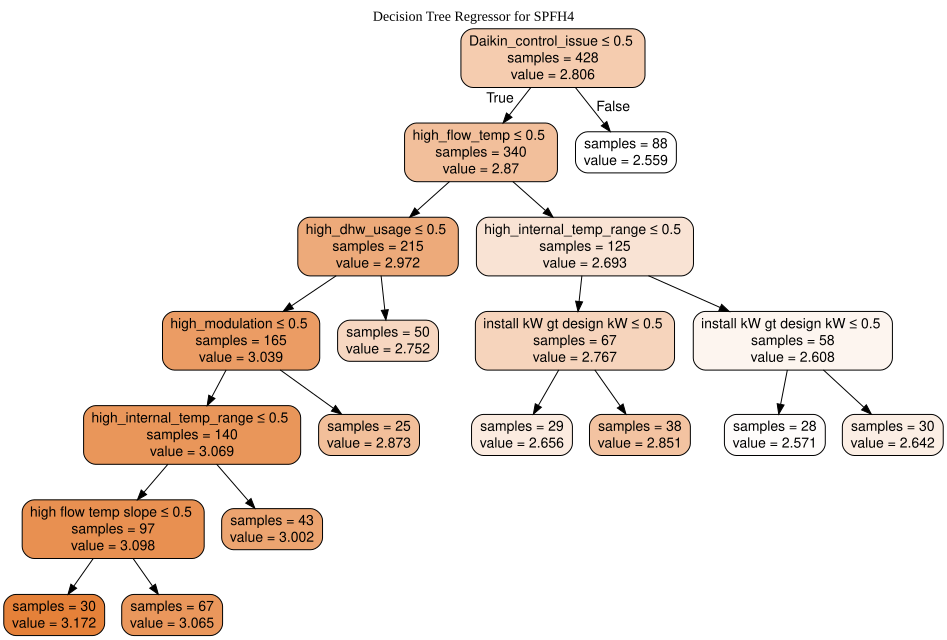

In [551]:
#homes_with_features = homes_with_features[homes_with_features["Low flow temp but low demand"]]

# Drop columns that are uniquely identifying / confounding, or variables we don't want in the model
# You can experiment with different variations, but I found this gave me the most explainable outputs
features = homes_with_features[[
                                "high_internal_temp_range",
                                #"install kW ~ design kW",
                                "install kW lt design kW",
                                "install kW gt design kW",
                                "lower_than_expected_SH",
                                #"actual_annual_SH_vs_design_SH",
                                #'percentage_time_on',
                                #'internal_temp_range',
                                'high_dhw_usage',
                                'high_modulation',
                                'high_flow_temp',
                                'Daikin_control_issue',
                                "short on, short off",
                                #"median_on_duration",
                                "high flow temp slope",
                                "on <30%",
                                "Daikin_control_issue",
                                #'DHW%',
                                ]]
categorical_cols = features.select_dtypes(include=['object', 'category']).columns
features = pd.get_dummies(features, columns=categorical_cols, drop_first=True)

# Note: If doing this properly to get a model we'd deploy, then we would do a test-train split 
# or cross validation to ensure that we're not overfitting to the data. Since we're just doing
# this for data exploration to understand potential causes of poor performance, rather than to
# actually predict whether it is performing well or not, we include all properties.
# That does mean we need to be careful about building trees that are too deep - those are more
# likely to be overfitting.

# Initializing and training the Decision Tree Regressor
regression_target = "SPFH4_selected_window"
regression_target_values = homes_with_features[regression_target]

# Note: If doing this properly to get a model we'd deploy, then we would do a test-train split 
# or cross validation to ensure that we're not overfitting to the data. Since we're just doing
# this for data exploration to understand potential causes of poor performance, rather than to
# actually predict whether it is performing well or not, we include all properties.
# That does mean we need to be careful about building trees that are too deep - those are more
# likely to be overfitting.

tree_regressor = DecisionTreeRegressor(random_state=4, max_depth=6, min_samples_leaf=25)
tree_regressor.fit(features, regression_target_values)

# Export the tree to Graphviz format
dot_data_reg = export_graphviz(tree_regressor, out_file=None, 
                           feature_names=features.columns,
                           impurity=False,  
                           filled=True, rounded=True,  
                           special_characters=True)
# Add a title manually by inserting a 'graph' property
dot_data_reg = dot_data_reg.replace("digraph Tree {", 'digraph Tree {\nlabel="Decision Tree Regressor for SPFH4";\nlabelloc="t";')

# Create and display the graph
graph_reg = graphviz.Source(dot_data_reg)
graph_reg.render("Decision Tree Regressor", format="png")
graph_reg


In [546]:
groups = homes_with_features.copy()

groups["group"] = None
groups.loc[groups["Daikin_control_issue"], "group"] = "Daikin control issue"
groups.loc[~groups["Daikin_control_issue"] & 
           groups["high_flow_temp"] &
           (groups["lower_than_expected_SH"] | groups["install kW gt design kW"]), "group"] = "High flow temperature and potential oversizing"
groups.loc[~groups["Daikin_control_issue"] & 
           groups["high_flow_temp"] &
           ~(groups["lower_than_expected_SH"] | groups["install kW gt design kW"]) &
           groups["high_internal_temp_range"], "group"] = "High flow temperature and low set back temperature? (maybe weather compensation)"
groups.loc[~groups["Daikin_control_issue"] & 
           groups["high_flow_temp"] &
           ~(groups["lower_than_expected_SH"] | groups["install kW gt design kW"]) &
           ~groups["high_internal_temp_range"], "group"] = "High flow temperature, steady internal temperature (maybe weather compensation)"
groups.loc[~groups["Daikin_control_issue"] & 
           ~groups["high_flow_temp"] &
           groups["high_dhw_usage"], "group"] = "Low flow temperature, but high hot water usage"
groups.loc[~groups["Daikin_control_issue"] & 
           ~groups["high_flow_temp"] &
           ~groups["high_dhw_usage"] &
           groups["high_modulation"], "group"] = "Low flow temperature, but high modulation - potential undersizing?"
groups.loc[~groups["Daikin_control_issue"] & 
           ~groups["high_flow_temp"] &
           ~groups["high_dhw_usage"] &
           ~groups["high_modulation"] &
           groups["high_internal_temp_range"], "group"] = "Low flow temperature, but high internal temperature variation - adjust set back temperature?"
groups.loc[~groups["Daikin_control_issue"] & 
           ~groups["high_flow_temp"] &
           ~groups["high_dhw_usage"] &
           ~groups["high_modulation"] &
           ~groups["high_internal_temp_range"] &
           groups["high flow temp slope"], "group"] = "Low flow temperature, but high flow temperature slope - maybe weather compensation curve is too high?"
groups.loc[~groups["Daikin_control_issue"] & 
           ~groups["high_flow_temp"] &
           ~groups["high_dhw_usage"] &
           ~groups["high_modulation"] &
           ~groups["high_internal_temp_range"] &
           ~groups["high flow temp slope"], "group"] = "No automatically identifiable issues"

In [547]:
groups

,Property_ID,HP_Installed,HP_Brand,HP_Model,HP_Size_kW,HP_Refrigerant,SPFH4_selected_window,HP_Energy_Output_selected_window,Mean_annual_SH_flow_temp_selected_window,Mean_annual_HW_flow_temp_selected_window,...,Undersized: install kW < design,Undersized: high modulation %,Undersized: high flow temp with long cycles,# Undersizing Indicators,"High Weather Comp: high flow temp, spikey","High Weather Comp: high flow temp, short cycles","High Weather Comp: high flow temp, high modulation",Low flow temp but low demand,Good_Performance,group
0,EOH0003,ASHP,Daikin,EDLQ07CAV7,7.0,R410A,2.502,8811.39,30.74,34.23,...,False,False,False,0,False,False,False,True,False,Daikin control issue
1,EOH0005,HT_ASHP,Vaillant,VWL 75/6 A 230V S2,7.0,R290,3.405,10964.88,35.60,38.82,...,False,False,False,0,False,False,False,False,True,"Low flow temperature, but high flow temperatur..."
2,EOH0021,ASHP,Mitsubishi,PUZ-WM85VAA-BS,8.5,R32,2.810,9248.67,33.97,36.94,...,False,False,False,0,False,False,False,False,False,"Low flow temperature, but high internal temper..."
3,EOH0026,ASHP,Daikin,EDLQ07CAV8,7.0,R410A,2.724,14116.03,37.76,38.26,...,False,True,False,1,False,False,False,True,False,Daikin control issue
4,EOH0031,HT_ASHP,Vaillant,VWL 75/6 A 230V S2,7.0,R290,2.901,17540.01,40.46,42.58,...,False,True,True,2,True,False,True,False,False,High flow temperature and low set back tempera...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423,EOH3177,ASHP,Mitsubishi,PUZ-WM85VAA,8.5,R32,2.646,16774.12,47.58,49.21,...,False,False,True,1,True,True,False,False,False,High flow temperature and potential oversizing
424,EOH3186,ASHP,Mitsubishi,PUZ-HWM140VHA,14.0,R32,3.216,28611.15,42.88,44.27,...,False,True,True,2,True,False,True,False,True,High flow temperature and potential oversizing
425,EOH3188,ASHP,Daikin,EDLQ011CAV3,11.0,R410A,2.550,10290.35,32.14,33.25,...,False,False,False,0,False,False,False,False,False,Daikin control issue
426,EOH3196,ASHP,Mitsubishi,PUHZ-W85VHAA,8.5,R410A,3.512,11223.91,37.96,39.16,...,False,False,False,0,False,False,False,False,True,"Low flow temperature, but high internal temper..."


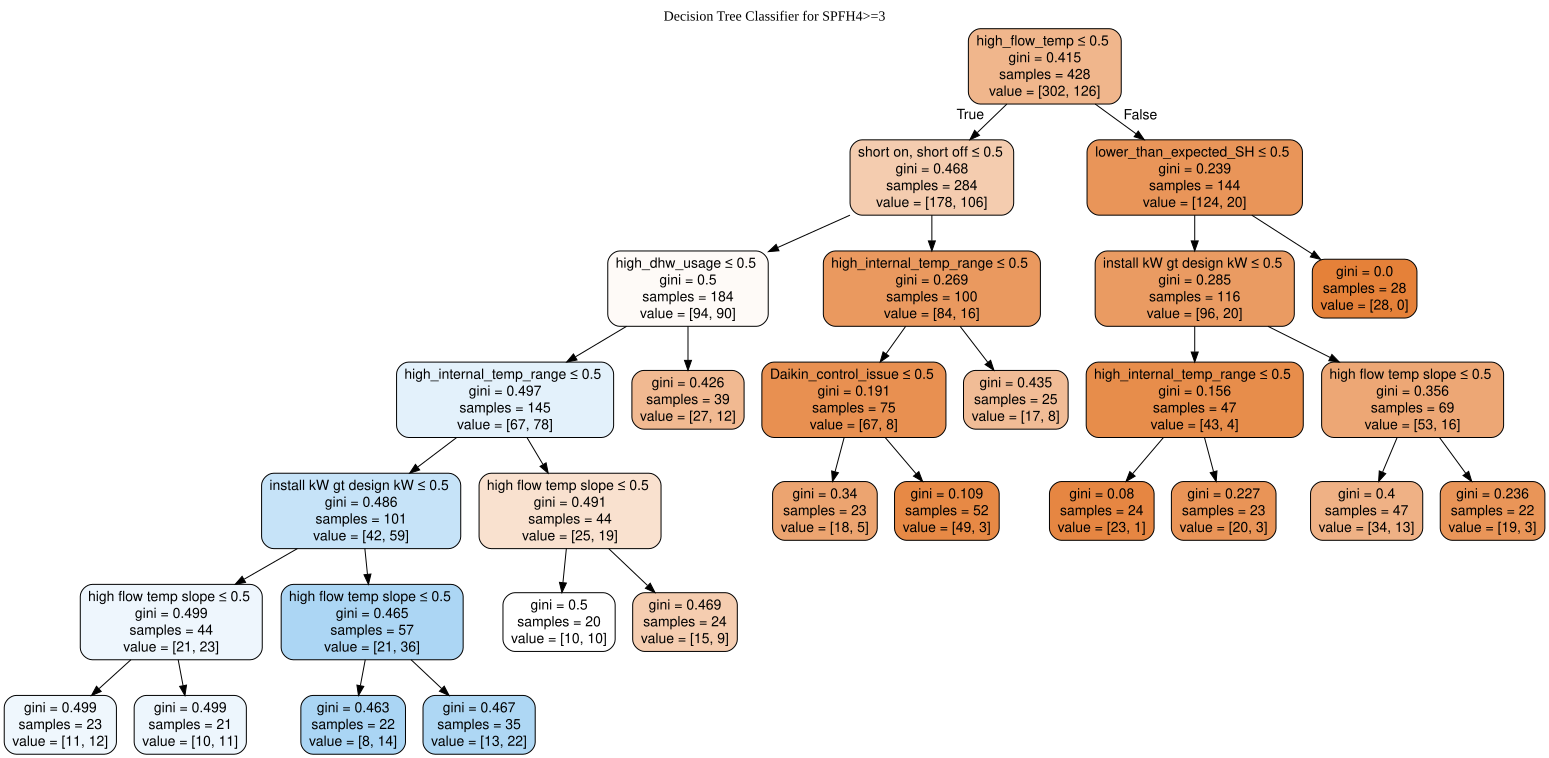

In [543]:
# Define "Good" performance as SPFH4 >= 3
homes_with_features["Good_Performance"] = homes_with_features["SPFH4_selected_window"] >= 3
target = "Good_Performance"
target_values = homes_with_features[target]

# Initializing and training the Decision Tree Classifier
tree_classifier = DecisionTreeClassifier(random_state=4, max_depth=6, min_samples_leaf=20)
tree_classifier.fit(features, target_values)

# Export the tree to Graphviz format
dot_data = export_graphviz(tree_classifier, out_file=None, 
                           feature_names=features.columns,  
                           filled=True, rounded=True,  
                           special_characters=True)
# Add a title manually by inserting a 'graph' property
dot_data = dot_data.replace("digraph Tree {", 'digraph Tree {\nlabel="Decision Tree Classifier for SPFH4>=3";\nlabelloc="t";')
graph = graphviz.Source(dot_data)
graph.render("Decision Tree Classifier", format="png")
graph

In [426]:
homes_with_features.columns

Index(['Property_ID', 'HP_Installed', 'HP_Brand', 'HP_Model', 'HP_Size_kW',
       'HP_Refrigerant', 'SPFH4_selected_window',
       'HP_Energy_Output_selected_window',
       'Mean_annual_SH_flow_temp_selected_window',
       'Mean_annual_HW_flow_temp_selected_window', 'Selected_window_start',
       'Selected_window_end', 'Delivery_Contractor', 'Name_Survey',
       'Name_Install', 'MCS_Flow_Temp', 'MCS_SCOP', 'MCS_SHLoad', 'MCS_Hloss',
       'MCS_SHAnnual', 'MCS_DHWAnnual', 'median_on_duration',
       'median_off_duration', 'median_hw_duration', 'median_flow_temp',
       'median_temp_change', 'mean_power', 'mean_modulation_pct',
       'median_cycles_per_day', 'median_internal_temp_winter',
       'tenth_pct_internal_temp_winter', 'percentage_time_on',
       'annual_hot_water_demand', 'annual_heating_demand',
       'power_weighted_flow_temperature', 'actual_DHW_vs_design_DHW',
       'actual_annual_SH_vs_design_SH', 'HP_Size_vs_SHLoad', 'HP_Size-SHLoad',
       'DHW%', 'on_to_o

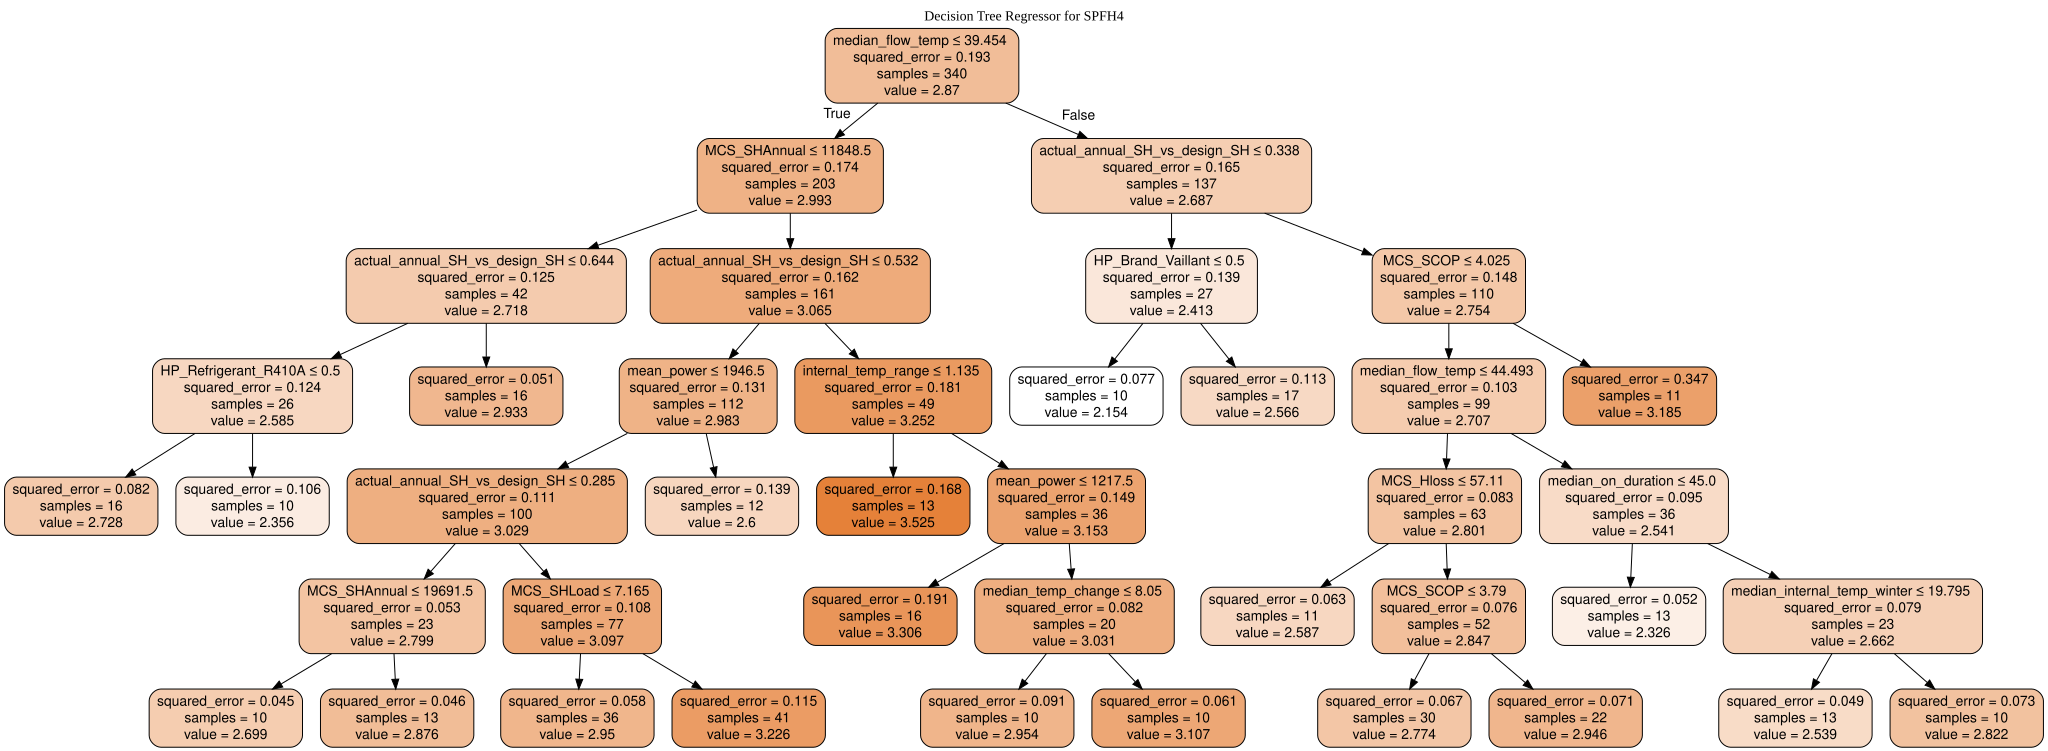

In [461]:
#homes_with_features = homes_with_features[homes_with_features["Low flow temp but low demand"]]

# Drop columns that are uniquely identifying / confounding, or variables we don't want in the model
# You can experiment with different variations, but I found this gave me the most explainable outputs
features = homes_with_features.drop(columns=[
                                "SPFH4_selected_window",
                                "Good_Performance",
                                'Mean_annual_HW_flow_temp_selected_window',
                                'Mean_annual_SH_flow_temp_selected_window',
                                'HP_Energy_Output_selected_window',
                                'annual_heating_demand',
                                'Property_ID',
                                'HP_Model',
                                'power_weighted_flow_temperature',
                                'on_to_off_duration_ratio'
                                ])
categorical_cols = features.select_dtypes(include=['object', 'category']).columns
features = pd.get_dummies(features, columns=categorical_cols, drop_first=True)

# Note: If doing this properly to get a model we'd deploy, then we would do a test-train split 
# or cross validation to ensure that we're not overfitting to the data. Since we're just doing
# this for data exploration to understand potential causes of poor performance, rather than to
# actually predict whether it is performing well or not, we include all properties.
# That does mean we need to be careful about building trees that are too deep - those are more
# likely to be overfitting.

# Initializing and training the Decision Tree Regressor
regression_target = "SPFH4_selected_window"
regression_target_values = homes_with_features[regression_target]

# Note: If doing this properly to get a model we'd deploy, then we would do a test-train split 
# or cross validation to ensure that we're not overfitting to the data. Since we're just doing
# this for data exploration to understand potential causes of poor performance, rather than to
# actually predict whether it is performing well or not, we include all properties.
# That does mean we need to be careful about building trees that are too deep - those are more
# likely to be overfitting.

tree_regressor = DecisionTreeRegressor(random_state=4, max_depth=6, min_samples_leaf=10)
tree_regressor.fit(features, regression_target_values)

# Export the tree to Graphviz format
dot_data_reg = export_graphviz(tree_regressor, out_file=None, 
                           feature_names=features.columns,  
                           filled=True, rounded=True,  
                           special_characters=True)
# Add a title manually by inserting a 'graph' property
dot_data_reg = dot_data_reg.replace("digraph Tree {", 'digraph Tree {\nlabel="Decision Tree Regressor for SPFH4";\nlabelloc="t";')

# Create and display the graph
graph_reg = graphviz.Source(dot_data_reg)
graph_reg.render("Decision Tree Regressor", format="png")
graph_reg


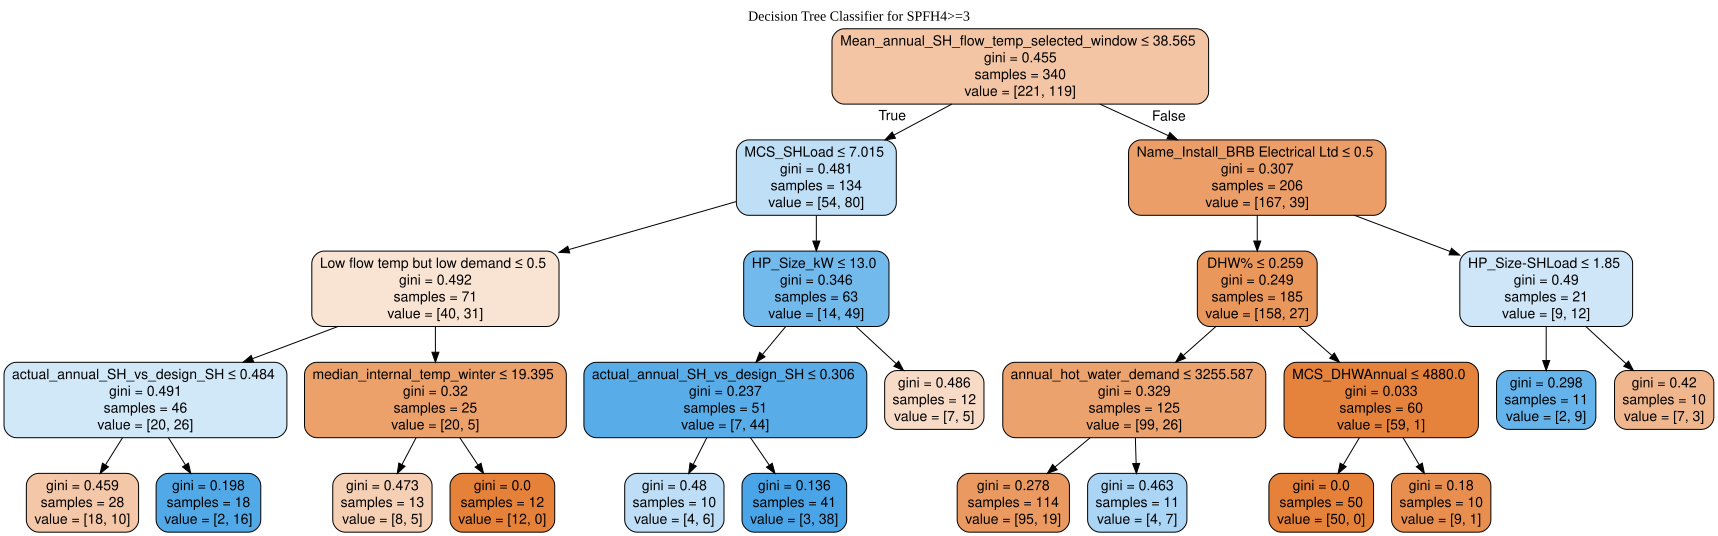

In [439]:
# Define "Good" performance as SPFH4 >= 3
homes_with_features["Good_Performance"] = homes_with_features["SPFH4_selected_window"] >= 3
target = "Good_Performance"
target_values = homes_with_features[target]

# Initializing and training the Decision Tree Classifier
tree_classifier = DecisionTreeClassifier(random_state=4, max_depth=4, min_samples_leaf=10)
tree_classifier.fit(features, target_values)

# Export the tree to Graphviz format
dot_data = export_graphviz(tree_classifier, out_file=None, 
                           feature_names=features.columns,  
                           filled=True, rounded=True,  
                           special_characters=True)
# Add a title manually by inserting a 'graph' property
dot_data = dot_data.replace("digraph Tree {", 'digraph Tree {\nlabel="Decision Tree Classifier for SPFH4>=3";\nlabelloc="t";')
graph = graphviz.Source(dot_data)
graph.render("Decision Tree Classifier", format="png")
graph

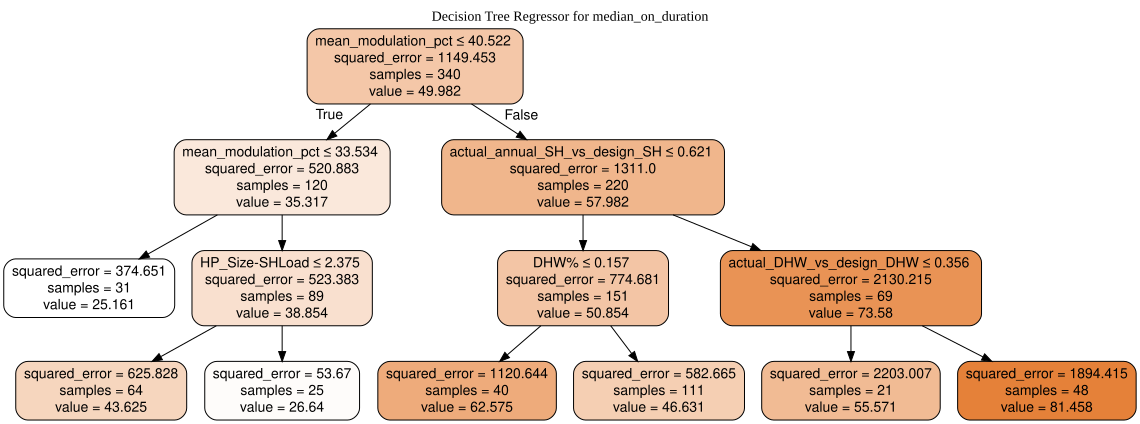

In [156]:


# Drop columns that are uniquely identifying / confounding, or variables we don't want in the model
# You can experiment with different variations, but I found this gave me the most explainable outputs
features2 = homes_with_features[[
                                #"median_on_duration",
                                #"median_off_duration",
                                #'power_weighted_flow_temperature',
                                "median_flow_temp",
                                "mean_modulation_pct",
                                #"median_cycles_per_day",
                                #'annual_hot_water_demand',
                                #'annual_heating_demand',
                                #'MCS_DHWAnnual',
                                #'HP_Size_kW',
                                #'MCS_SHAnnual',
                                #'MCS_SHLoad', 
                                #'MCS_Hloss',
                                'actual_DHW_vs_design_DHW',
                                'actual_annual_SH_vs_design_SH',
                                'HP_Size_vs_SHLoad',
                                'HP_Size-SHLoad',
                                'DHW%',
                                'high_dhw_usage',
                                'lower_than_expected_SH',
                                'high_flow_temp',
                                'Daikin_control_issue'
                                ]]
categorical_cols = features2.select_dtypes(include=['object', 'category']).columns
features2 = pd.get_dummies(features2, columns=categorical_cols, drop_first=True)

# Note: If doing this properly to get a model we'd deploy, then we would do a test-train split 
# or cross validation to ensure that we're not overfitting to the data. Since we're just doing
# this for data exploration to understand potential causes of poor performance, rather than to
# actually predict whether it is performing well or not, we include all properties.
# That does mean we need to be careful about building trees that are too deep - those are more
# likely to be overfitting.

# Initializing and training the Decision Tree Regressor
regression_target2 = "median_on_duration"
regression_target_values2 = homes_with_features[regression_target2]

# Note: If doing this properly to get a model we'd deploy, then we would do a test-train split 
# or cross validation to ensure that we're not overfitting to the data. Since we're just doing
# this for data exploration to understand potential causes of poor performance, rather than to
# actually predict whether it is performing well or not, we include all properties.
# That does mean we need to be careful about building trees that are too deep - those are more
# likely to be overfitting.

tree_regressor2 = DecisionTreeRegressor(random_state=4, max_depth=3, min_samples_leaf=20)
tree_regressor2.fit(features2, regression_target_values2)

# Export the tree to Graphviz format
dot_data_reg2 = export_graphviz(tree_regressor2, out_file=None, 
                           feature_names=features2.columns,  
                           filled=True, rounded=True,  
                           special_characters=True)
# Add a title manually by inserting a 'graph' property
dot_data_reg2 = dot_data_reg2.replace("digraph Tree {", 'digraph Tree {\nlabel="Decision Tree Regressor for median_on_duration";\nlabelloc="t";')

# Create and display the graph
graph_reg2 = graphviz.Source(dot_data_reg2)
graph_reg2.render("Decision Tree Regressor oon duration", format="png")
graph_reg2


In [18]:
groups = homes_with_features.copy()
groups["Group"] = None


groups["Daikin_control_issue"] = (groups["HP_Brand"] == "Daikin") & (groups["median_off_duration"] <= 6)

# The better performing heat pumps - long periods at lower flow temperatures
groups.loc[(groups["median_on_duration"] > 21)
           & (groups["median_flow_temp"] < 39.3)
           & (groups["median_off_duration"] <= 15), "Group"] = "Long cycles at low temperature, short gaps"
groups.loc[(groups["median_on_duration"] > 21)
           & (groups["median_flow_temp"] < 39.3)
           & (groups["median_off_duration"] > 15), "Group"] = "Long cycles at low temperature, longer gaps"

# Shorter cycles
groups.loc[(groups["median_on_duration"] <= 21)
           & (groups["median_flow_temp"] >= 36.75), "Group"] = "Short cycles at high temperature"
groups.loc[(groups["median_on_duration"] <= 21)
           & (groups["median_flow_temp"] < 36.75)
           & (groups["median_hw_duration"] > 87), "Group"] = "Short cycles at low temperature with shorter hot water"
groups.loc[(groups["median_on_duration"] <= 21)
           & (groups["median_flow_temp"] < 36.75)
           & (groups["median_hw_duration"] <= 87), "Group"] = "Short cycles at low temperature with longer hot water"

# Longer cycles at higher temperatures
groups.loc[(groups["median_on_duration"] > 21)
           & (groups["median_flow_temp"] >= 39.3), "Group"] = "Long cycles at higher temperatures"

In [5]:
groups.groupby("Group").agg(count=("Property_ID", "count"),
                            median_spfh4=("SPFH4_selected_window", "median"),
                            pct_with_spfh4_gt_3=("Good_Performance", "mean"))

,count,median_spfh4,pct_with_spfh4_gt_3
Group,,,
Long cycles at higher temperatures,138,2.6955,0.159420
"Long cycles at low temperature, longer gaps",153,2.9770,0.483660
"Long cycles at low temperature, short gaps",17,3.2570,0.764706
Short cycles at high temperature,30,2.4095,0.066667
Short cycles at low temperature with longer hot water,80,2.6680,0.137500
Short cycles at low temperature with shorter hot water,10,2.9345,0.400000


In [6]:
px.histogram(groups, x="median_off_duration", color="HP_Brand")

In [7]:
px.histogram(groups, x="median_on_duration", color="HP_Brand")

In [8]:
px.scatter(groups, x="median_on_duration", y="median_off_duration", color="HP_Brand", width=600)

In [9]:
fig = px.scatter(groups, x="median_on_duration", y="median_flow_temp", color="HP_Brand", width=600)
fig.show()

In [17]:
fig = px.scatter(groups, x="median_off_duration", y="median_flow_temp", color="HP_Brand", title="Lots of Daikins had extremely short gaps between cycles", width=600)
fig.show()

In [15]:
fig = px.scatter(groups, x="median_off_duration", y="median_on_duration", color="HP_Brand", title="", width=600)
fig.show()

In [14]:
fig = px.scatter(groups, x="median_off_duration", y="median_flow_temp", color="SPFH4_selected_window", width=800, height=700)
fig.show()

In [24]:
fig = px.scatter(groups[groups["Daikin_control_issue"]], x="median_flow_temp", y="SPFH4_selected_window", width=800, height=700)
fig.show()

In [27]:
groups["flow_temp_band"] = (groups["median_flow_temp"] / 5).round() * 5

In [28]:
groups.groupby(["Daikin_control_issue", "flow_temp_band"])["SPFH4_selected_window"].describe()

count      mean       std    min  \
Daikin_control_issue flow_temp_band                                     
False                20.0              9.0  2.660556  0.299465  2.122   
                     30.0             36.0  3.100611  0.553731  1.848   
                     35.0            118.0  3.003008  0.387720  1.664   
                     40.0             93.0  2.851484  0.331840  2.073   
                     45.0             64.0  2.645719  0.371797  1.472   
                     50.0             12.0  2.455667  0.437437  1.472   
                     55.0              7.0  2.837571  0.912586  2.074   
                     60.0              1.0  1.941000       NaN  1.941   
True                 25.0             14.0  2.564643  0.295334  1.937   
                     30.0             23.0  2.545435  0.316594  1.763   
                     35.0             29.0  2.639517  0.374913  2.009   
                     40.0             11.0  2.456818  0.257193  2.015   
                     45.0              8.0  2.415375  0.395563  1.575   
                     50.0              3.0  2.615333  0.164135  2.435   

                                         25%     50%      75%    max  
Daikin_control_issue flow_temp_band                                   
False                20.0            2.54700  2.8090  2.84400  2.970  
                     30.0            2.81750  3.0995  3.41125  4.682  
                     35.0            2.73975  3.0010  3.26400  3.892  
                     40.0            2.65200  2.8430  3.01100  4.003  
                     45.0            2.40700  2.6600  2.89250  3.643  
                     50.0            2.30775  2.5225  2.65725  3.275  
                     55.0            2.35600  2.6290  2.82800  4.792  
                     60.0            1.94100  1.9410  1.94100  1.941  
True                 25.0            2.34550  2.6200  2.75650  3.082  
                     30.0            2.41650  2.6570  2.72750  3.002  
                     35.0            2.42200  2.6980  2.79000  3.412  
                     40.0            2.31700  2.4080  2.61400  2.888  
                     45.0            2.37225  2.4575  2.65050  2.808  
                     50.0            2.54500  2.6550  2.70550  2.756

In [31]:
px.box(groups, x="flow_temp_band", y="SPFH4_selected_window", color="Daikin_control_issue", width=800)